In [1]:
import duckdb

In [2]:
con = duckdb.connect("research.duckdb")

In [3]:
con.execute("SHOW TABLES").df() 

,name
0,current_eps_features
1,current_eps_raw
2,historical_eps_features
3,historical_news_clean
4,historical_prices_clean
5,master_developments
6,master_historical_eps
7,master_historical_prices
8,signal_price


0. current_eps_features: table of current stock eps data with z-scores
1. current_eps_raw: the raw eps data from excel, no z-scores
2. master_developments: This has every relevant news headline and description for our universe going back to 2014
3. master_historical_eps: This has the loaded historical eps data
4. master_historical_prices: This has the laoded historical price data

- historical_price_clean: prices with no NAN in adj_close column
- historical_eps_features: historical eps data with z-scores
- signal_price: table with the eps z-scores and prices 

Deleted Tables
1. dates_w_universe: ~7,500 companies in our historical universe. Also the dates which we will extract data for
2. historical_eps_formula: for each company in 'dates_w_universe', there is a corresponding row for every date. For every row there is a CIQ exel formula, which if opened in excel and reloaded, will download the needed data. Earnings per share estimates
3. historical_price_formula: for each company in 'dates_w_universe', there is a corresponding row for every date. For every row there is a CIQ exel formula, which if opened in excel and reloaded, will download the needed data. Price and volume data

#### Create table with historical z-values for eps estimate reversion

In [4]:

# This is how you would add the 3 months ago eps estimate to a table.
# Running the code multiple times seems to result in a different output for some reason.
con.execute("""
            CREATE OR REPLACE TABLE historical_eps_features AS
            WITH features AS (
            SELECT 
                p1.AS_OF,
                p1.IQID,
                p1.company_name,
                p1.sector,
                p1.marketcap,
                p1.num_est,
                p1.eps_est as eps_est,
                p2.eps_est as eps_est_1m,
                p3.eps_est as eps_est_3m
            FROM master_historical_eps p1
            LEFT JOIN master_historical_eps p2
                ON p1.IQID = p2.IQID
                AND DATE_TRUNC('month', p2.AS_OF) = DATE_TRUNC('month', p1.AS_OF - INTERVAL 1 MONTH)
            LEFT JOIN master_historical_eps p3
                ON p1.IQID = p3.IQID
                AND DATE_TRUNC('month', p3.AS_OF) = DATE_TRUNC('month', p1.AS_OF - INTERVAL 3 MONTH)
            ORDER BY p1.company_name, p1.IQID, p1.AS_OF
            --LIMIT 50 OFFSET 130
            )

            SELECT
                *,
                CASE 
                    WHEN eps_est_1m IS NULL OR ABS(eps_est_1m) < 1e-6 THEN NULL
                    ELSE (eps_est - eps_est_1m) / ABS(eps_est_1m)
                END AS rev_1m,
                CASE 
                    WHEN eps_est_3m IS NULL OR ABS(eps_est_3m) < 1e-6 THEN NULL
                    ELSE (eps_est - eps_est_3m) / ABS(eps_est_3m)
                END AS rev_3m,
                CASE
                    WHEN STDDEV_POP(rev_1m) OVER (PARTITION BY AS_OF, sector) < 1e-8 THEN NULL
                    ELSE (rev_1m - AVG(rev_1m) OVER (PARTITION BY AS_OF, sector)) /
                        (STDDEV_POP(rev_1m) OVER (PARTITION BY AS_OF, sector)) 
                END AS z_1m,
                CASE
                    WHEN STDDEV_POP(rev_3m) OVER (PARTITION BY AS_OF, sector) < 1e-8 THEN NULL
                    ELSE (rev_3m - AVG(rev_3m) OVER (PARTITION BY AS_OF, sector)) / 
                        (STDDEV_POP(rev_3m) OVER (PARTITION BY AS_OF, sector)) 
                END AS z_3m,
                0.5 * z_1m + 0.5 * z_3m AS signal

            
            FROM features
            -- this is maybe something to consider in terms of bias...
            --WHERE eps_est_3m IS NOT NULL

""")

#### Add prices to historical eps z-value table

In [5]:
con.execute("""
CREATE OR REPLACE TABLE signal_price AS
SELECT
    e.as_of,
    e.iqid,
    e.sector,
    e.marketcap,
    e.rev_1m,
    e.rev_3m,
    e.z_1m,
    e.z_3m,
    e.signal,
    e.num_est,
    p.volume,
    p.adj_close,
    p.as_of as price_date
FROM historical_eps_features e
JOIN master_historical_prices p
    ON e.iqid = p.iqid
    AND p.as_of >= e.as_of
    AND p.as_of <= e.as_of + INTERVAL 10 DAY
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY e.iqid, e.as_of
    ORDER BY p.as_of
) = 1
            
ORDER BY e.iqid, e.as_of

""")

In [6]:
con.execute("SELECT * FROM signal_price LIMIT 10").df()

,AS_OF,IQID,sector,marketcap,rev_1m,rev_3m,z_1m,z_3m,signal,num_est,volume,adj_close,price_date
0,2014-09-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2014-09-02
1,2014-10-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2014-10-01
2,2014-11-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2014-11-03
3,2014-12-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2014-12-01
4,2015-01-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2015-01-02
5,2015-02-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2015-02-02
6,2015-03-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2015-03-02
7,2015-04-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2015-04-01
8,2015-05-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2015-05-01
9,2015-06-01,12288,Financials,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,2015-06-01


### calculate returns and do analysis on signal

In [7]:
signal_return_df = con.execute("""
            SELECT
                as_of,
                iqid,
                signal,
                LEAD(adj_close, 1) OVER (PARTITION BY iqid ORDER BY price_date) / adj_close - 1 AS fwd_1m,
                LEAD(adj_close, 3) OVER (PARTITION BY iqid ORDER BY price_date) / adj_close - 1 AS fwd_3m
            FROM signal_price
""").df()


long_short_1m=0.00607
long_short_3m=0.01721
Average return of basic strategy: 0.0059


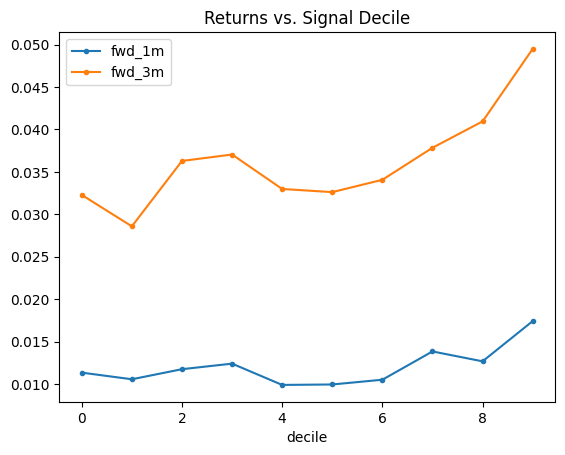

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = signal_return_df.copy()

df = df.dropna(subset=['signal', 'fwd_1m', 'fwd_3m'])

# create a column of the decile
# for every date, the signal strength is ranked and placed into 10 categories
# "on this date, which decile is this signal in"
# transform() returns things to the exact same shape as before. It calculates the deciles
# and then returns a decile for each row, rather than collapsing down like .mean() or .sum()
df["decile"] = df.groupby("AS_OF")["signal"]\
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))

# get average 1m and 3m returns over each decile
decile_returns = df.groupby("decile")[["fwd_1m", "fwd_3m"]].mean()
decile_returns.plot(marker='.', title='Returns vs. Signal Decile')

# assuming our strategy longs the top decile and shorts the bottom, what is our return?
long_short_1m = decile_returns.loc[9, "fwd_1m"] - decile_returns.loc[0, "fwd_1m"]
long_short_3m = decile_returns.loc[9, "fwd_3m"] - decile_returns.loc[0, "fwd_3m"]

print(f'\n{long_short_1m=:.5f}\n{long_short_3m=:.5f}')

# compute the average 1 month forward return for each decile
ls = df.groupby(["AS_OF", "decile"])["fwd_1m"].mean().unstack()
# get the monthly strategy returns if we long top decile, short bottom decile
ls["long_short"] = ls[9] - ls[0]

print(f'Average return of basic strategy: {ls["long_short"].mean():.4f}')  # average return

This seems to be a promising signal, just longing the top decile and shorting the bottom decile, we get a monthly return of 0.59% (7.08% annually).

Now, I will see if I can strengthen the signal.

### Trying to find a stronger strategy

I will use a different mix of 1m and 3m z-values as the signal. I will filter out small companies and companies who don't have a certain number of eps estimages.

In [10]:
signal_return_df_ext = con.execute("""
            SELECT
                as_of,
                iqid,
                sector,
                marketcap,
                num_est,
                rev_1m,
                rev_3m,
                z_1m,
                z_3m,
                LEAD(adj_close, 1) OVER (PARTITION BY iqid ORDER BY price_date) / adj_close - 1 AS fwd_1m,
                LEAD(adj_close, 3) OVER (PARTITION BY iqid ORDER BY price_date) / adj_close - 1 AS fwd_3m
            FROM signal_price
""").df()




long_short_1m=0.00870
long_short_3m=0.02137
Average return of basic strategy: 0.0085


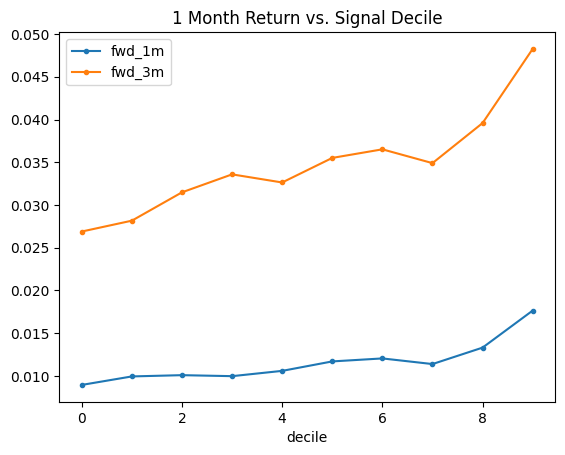

In [11]:

df = signal_return_df_ext.copy()

# remove small number of estimates
df = df[df['num_est'] >= 3]
# remove small companies
#df = df[df['marketcap'] > 5000]
# remove large revisions
df = df[df["rev_1m"].abs() < 5]


# weights of z-values for signal
w1 = 0.0
w2 = 1.0 - w1
df['signal'] = w1 * df['z_1m'] + w2 * df['z_3m']

df = df.dropna(subset=['signal', 'fwd_1m', 'fwd_3m'])

# create a column of the decile
# for every date, the signal strength is ranked and placed into 10 categories
# we also group by sector now

# df["decile"] = df.groupby(["AS_OF", "sector"])["signal"]\
#     .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))
# The plot looks a lot smoother if I don't group by sector, but the returns are higher if I do.
df["decile"] = df.groupby(["AS_OF"])["signal"]\
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))

# get average 1m and 3m returns over each decile
decile_returns = df.groupby("decile")[["fwd_1m", "fwd_3m"]].mean()
decile_returns.plot(marker='.', title='1 Month Return vs. Signal Decile')

# assuming our strategy longs the top decile and shorts the bottom, what is our return?
long_short_1m = decile_returns.loc[9, "fwd_1m"] - decile_returns.loc[0, "fwd_1m"]
long_short_3m = decile_returns.loc[9, "fwd_3m"] - decile_returns.loc[0, "fwd_3m"]

print(f'\n{long_short_1m=:.5f}\n{long_short_3m=:.5f}')
# compute the average 1 month forward return for each decile
ls = df.groupby(["AS_OF", "decile"])["fwd_1m"].mean().unstack()
# get the monthly strategy returns if we long top decile, short bottom decile
ls["long_short"] = ls[9] - ls[0]

print(f'Average return of basic strategy: {ls["long_short"].mean():.4f}')  # average return

The signal is now better with the conditions, so we can move on to developing the real signal with news sentiment.